# Библиотеки

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from sklearn.metrics import pairwise_distances_argmin, pairwise_distances
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from scipy.sparse import vstack

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from scipy.sparse import vstack
from sklearn.metrics import f1_score

# Данные

In [ ]:
from sklearn.datasets import fetch_20newsgroups

newsgroups_train = fetch_20newsgroups(subset='train')
newsgroups_test = fetch_20newsgroups(subset='test')

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(min_df=3)

train_tfidf = tfidf.fit_transform(newsgroups_train.data)
test_tfidf = tfidf.transform(newsgroups_test.data)

In [ ]:
train_tfidf.shape

(11314, 38869)

In [ ]:
len(tfidf.vocabulary_)

38869

In [ ]:
PRICE_THRESHOLD = 1_000_000

def get_text_prices(texts):
    return np.array([len(text.split()) for text in texts])

In [ ]:
def evaluate_solution(labeled_indices):
    newsgroups_train = fetch_20newsgroups(subset='train')
    newsgroups_test = fetch_20newsgroups(subset='test')

    price = get_text_prices(newsgroups_train.data)[labeled_indices].sum()
    if price > PRICE_THRESHOLD:
        raise RuntimeError(f'Your budget is {PRICE_THRESHOLD} words, but you want to label {price} words.')

    tfidf = TfidfVectorizer(min_df=3)

    train_tfidf = tfidf.fit_transform(newsgroups_train.data)
    test_tfidf = tfidf.transform(newsgroups_test.data)

    model = MultinomialNB(alpha=0.01)

    features = vstack(train_tfidf[labeled_indices])
    labels = newsgroups_train.target[labeled_indices]

    model.fit(features, labels)

    preds = model.predict(test_tfidf)
    f1 = f1_score(newsgroups_test.target, preds, average='macro')

    return f1

# Активное обучение

In [ ]:
unlabeled_data = np.array(list(zip(train_tfidf, newsgroups_train.target)))

In [ ]:
class ActiveLearning:
    def __init__(self, unlabeled_data, min_training_items=512, label_num=128):
        self.unlabeled_data = np.array(unlabeled_data)
        self.labeled_data = []
        self.unlabeled_idxs = np.arange(len(self.unlabeled_data))
        self.labeled_idxs = []

        # модель, которую мы будем обучать
        self.model = MultinomialNB(alpha=0.01)
        # число стартовых размеченных текстов
        self.min_training_items = min_training_items
        # число текстов для разметки на каждом шаге
        self.label_num = label_num

    def init_labeled_data(self):
        """
        Выбираем случайные стартовые тексты для разметки
        """
        np.random.seed(10)
        idxs = np.random.choice(
            np.arange(len(self.unlabeled_data)),
            size=self.min_training_items,
            replace=False
        )

        self.labeled_data = self.unlabeled_data[idxs]
        self.labeled_idxs.extend(self.unlabeled_idxs[idxs])
        self.unlabeled_data = np.delete(self.unlabeled_data, idxs, 0)
        self.unlabeled_idxs = np.delete(self.unlabeled_idxs, idxs, 0)


    def get_probs(self):
        """
        Возвращает предсказания вероятностей для всех неразмеченных текстов
        """
        x = self.unlabeled_data[:, 0]
        x = vstack(x)
        probs = self.model.predict_proba(x)
        return probs

    def get_scores(self):
        """
        Возвращает оценки для всех неразмеченных текстов.
        На основе этих оценок происходит выбор текстов для разметки.
        """
        if len(self.unlabeled_data) <= self.label_num:
            return np.zeros(len(self.unlabeled_data))

        return np.random.rand(len(self.unlabeled_data))

    def label_additional_data(self):
        """
        Размечает порцию текстов в соответствии с их оценками
        """
        if len(self.labeled_data) == 0:
            self.init_labeled_data()
            return

        scores = self.get_scores()
        idxs = np.argsort(scores)[-self.label_num:]

        self.labeled_data = np.concatenate((self.labeled_data, self.unlabeled_data[idxs]))
        self.labeled_idxs.extend(self.unlabeled_idxs[idxs])
        self.unlabeled_data = np.delete(self.unlabeled_data, idxs, 0)
        self.unlabeled_idxs = np.delete(self.unlabeled_idxs, idxs, 0)

    def train_model(self):
        """
        Обучает модель на всех размеченных текстах
        """
        assert len(self.labeled_data) > 0, "You don't have any labeled data"

        x = self.labeled_data[:, 0]
        x = vstack(x)
        y = self.labeled_data[:, 1].astype(int)
        self.model.fit(x, y)

# Run_active_learning

In [ ]:
def get_text_prices(texts):
    return np.array([len(text.split()) for text in texts])

In [ ]:
from typing import List


text_prices = get_text_prices(newsgroups_train.data)
PRICE_THRESHOLD = 1_000_000


def run_active_learning(
    unlabeled_data: np.ndarray,
    al_classes: List[ActiveLearning],
    names: List[str]
):
    """
    Запускает процесс активного обучения для всех классов `al_classes`
    и сохраняет траектории F1 и стоимостей разметки в процессе доразметки

    params:
      - unlabeled_data: массив с неразмеченными данными, совпадает с объявленным выше
      - al_classes: список классов, наследованных от ActiveLearning
      - names: список строковых названий методов из al_classes

    return:
      dict{<name>: {
          'f1': <f1_trajectory>,  # траектории значений F1 на тестовой выборке в ходе доразметки
          'price': <price_trajectory>,  # траектории стоимости всех размеченных текстов на каждом шаге
          'labeled_indices': <labeled_indices>  # лучший набор индексов текстов для разметки, влезающих
                                                # в бюджет по мнению метода <name>
      }}
    """

    results = dict()

    for al_class, name in zip(al_classes, names):
        al = al_class(unlabeled_data, min_training_items=512, label_num=128)
        al.init_labeled_data()

        f1_scores = []
        costs = []
        labeled_indices = []
        total_price = 0

        while len(al.unlabeled_data) > 0:

            culk_price = text_prices[al.labeled_idxs].sum()

            if culk_price >= PRICE_THRESHOLD:
                al.labeled_idxs = al.labeled_idxs[:-al.label_num]
                break
            total_price += culk_price
            costs.append(total_price)

            al.label_additional_data()
            al.train_model()

            test_pred = al.model.predict(test_tfidf)
            f1 = f1_score(newsgroups_test.target, test_pred, average='macro')
            f1_scores.append(f1)

            labeled_indices = al.labeled_idxs.copy()

        results[name] = {
            "f1": f1_scores,
            "price": costs,
            "labeled_indices": labeled_indices,
        }

    return results

In [ ]:
vac = run_active_learning(unlabeled_data, [ActiveLearning], ['Base'])

In [ ]:
def plot_results(results):
    """
    Отрисовывает траектории, полученные из `run_active_learning`
    """

    plt.figure(figsize=(10, 3))

    plt.subplot(1, 2, 1)
    for name, values in results.items():
        plt.plot(values['f1'], label=name)
    plt.legend()
    plt.title('F1', size=16)
    plt.xlabel('AL steps', size=14)
    plt.grid()

    plt.subplot(1, 2, 2)
    for name, values in results.items():
        plt.plot(values['price'], label=name)
    plt.legend()
    plt.title('Price', size=16)
    plt.xlabel('AL steps', size=14)
    plt.grid()

    plt.show()

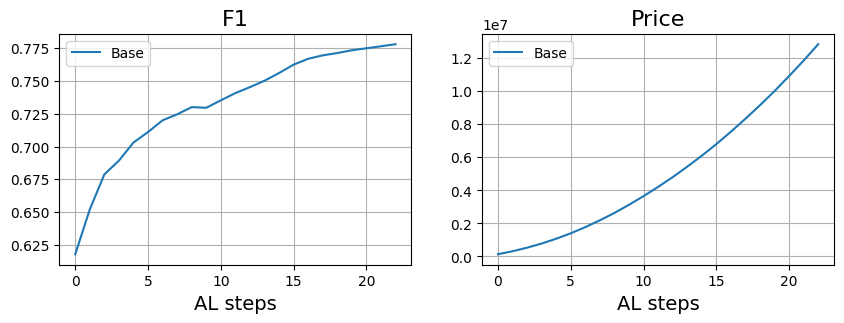

In [ ]:
plot_results(vac)

# Инициализация кластерами

In [ ]:
class ClusterInitAL(ActiveLearning):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def init_labeled_data(self):
        """
        Проводит кластеризацию и выбирает центры кластеров для разметки
        """

        x = self.unlabeled_data[:, 0]
        x = vstack(x)

        lsa = make_pipeline(TruncatedSVD(n_components=100), Normalizer(copy=False))
        x_lsa = lsa.fit_transform(x)

        kmeans = KMeans(n_clusters= self.min_training_items).fit(x_lsa)
        closest_idxs = list(pairwise_distances_argmin(kmeans.cluster_centers_, x_lsa))

        self.labeled_data = self.unlabeled_data[closest_idxs]
        self.labeled_idxs.extend(self.unlabeled_idxs[closest_idxs])
        self.unlabeled_data = np.delete(self.unlabeled_data, closest_idxs, 0)
        self.unlabeled_idxs = np.delete(self.unlabeled_idxs, closest_idxs, 0)

        return closest_idxs


In [ ]:
results = run_active_learning(unlabeled_data, [ActiveLearning, ClusterInitAL], names=['Random', 'Cluster init'])

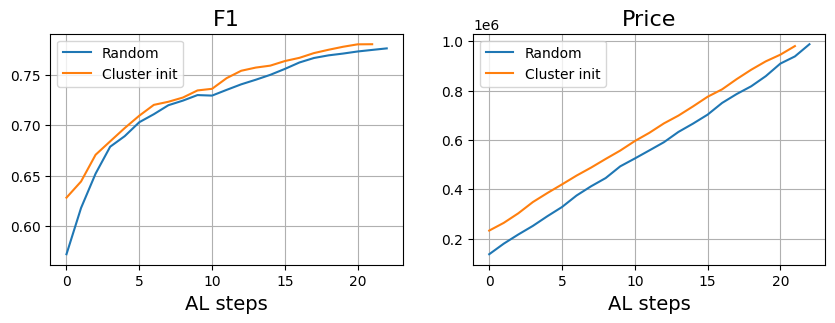

In [ ]:
plot_results(results)

# Query by Committee

In [ ]:
class QueryCommitteeAL(ActiveLearning):
    def __init__(self, *args, n_classes=20, **kwargs):
        super().__init__(*args, **kwargs)


        self.n_classes = n_classes
        self.models = [MultinomialNB(alpha=0.01), MultinomialNB(alpha=0.01)]

    def train_committee(self):

     bootstrap_idx = [np.random.choice(
            np.arange(len(self.labeled_data)),
            size=len(self.labeled_data),
            replace=True
        )
     for _ in range(2)
     ]

     for model, idxs in zip(self.models, bootstrap_idx):
            X_train = vstack(self.labeled_data[idxs, 0])  # Преобразуем в разреженную матрицу
            y_train = self.labeled_data[idxs, 1].astype(int)
            model.fit(X_train, y_train)

    def get_scores(self):

        self.train_committee()

        prediction = np.array([model.predict(vstack(self.unlabeled_data[:, 0])) for model in self.models])

        score_total = []
        for i in range(len(self.unlabeled_data)):

            count = np.bincount(prediction[:, i], minlength=self.n_classes)

            share = count/len(self.models)

            share += 1e-10

            score = -sum(share * np.log(share))

            score_total.append(score)

        return score_total

In [ ]:
results = run_active_learning(unlabeled_data, [ActiveLearning, QueryCommitteeAL], names=['Random', 'QueryCommitteeAL'])

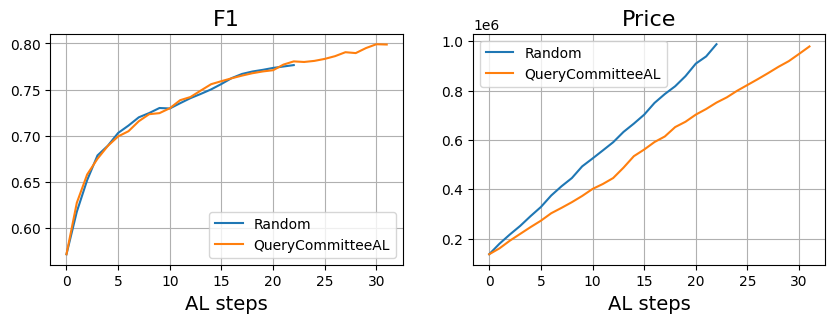

In [ ]:
plot_results(results)

# Uncertainty & Clustering

In [ ]:
class LeastConfClusterAL(ActiveLearning):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def get_scores(self):
        if len(self.unlabeled_data) <= self.label_num:
          return np.zeros(len(self.unlabeled_data))

        probs = self.get_probs()
        least_conf_score = 1 - probs.max(axis=1)

        percent = min(1, self.label_num * 2 / len(least_conf_score))
        topk_idxs = np.argsort(least_conf_score)[-int(len(least_conf_score) * percent):]

        # Берём элементы подвыборки с индексами topk_idxs
        subset = self.unlabeled_data[topk_idxs][:, 0]

        # Если элементы subset — разреженные матрицы / векторы размером (1, num_features),
        # собрать их вертикально через vstack
        x = vstack(subset)


        # Далее применяем LSA и кластеризацию
        lsa = make_pipeline(TruncatedSVD(n_components=100), Normalizer(copy=False))
        x_lsa = lsa.fit_transform(x)


        kmeans = KMeans(n_clusters=min(self.label_num, len(self.unlabeled_data))).fit(x_lsa)
        closest_idxs = np.unique(list(pairwise_distances_argmin(kmeans.cluster_centers_, x_lsa)))

        selected_idxs = topk_idxs[closest_idxs]

        scores = np.zeros(len(self.unlabeled_data))
        scores[selected_idxs] = 1

        return scores


In [ ]:
results = run_active_learning(unlabeled_data, [ActiveLearning, LeastConfClusterAL], names=['Random', 'LeastConfClusterAL'])

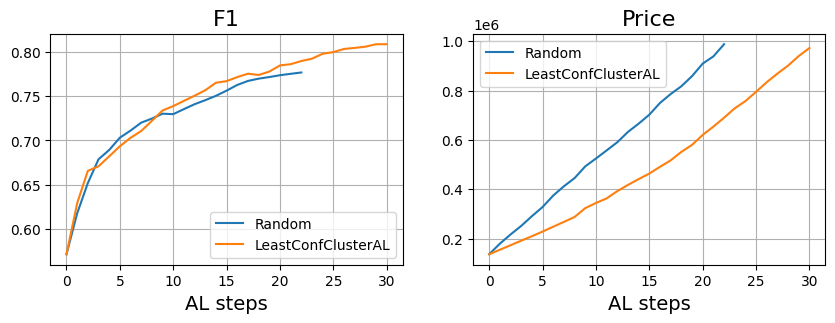

In [ ]:
plot_results(results)